In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")


In [2]:
data = pd.read_csv("../data/data.csv")
genre_data = pd.read_csv("../data/data_by_genres.csv")
year_data = pd.read_csv("../data/data_by_year.csv")

In [3]:
data_1980 = data[data["year"] >= 1980].copy()

In [4]:
data_1980["year"].min()

np.int64(1980)

In [5]:
print("Original dataset:", data.shape)
print("1980+ dataset:", data_1980.shape)

Original dataset: (170653, 19)
1980+ dataset: (81201, 19)


In [6]:
data_1980["danceability"]

11606     0.310
11607     0.774
11608     0.933
11609     0.751
11610     0.532
          ...  
170648    0.786
170649    0.717
170650    0.634
170651    0.671
170652    0.856
Name: danceability, Length: 81201, dtype: float64

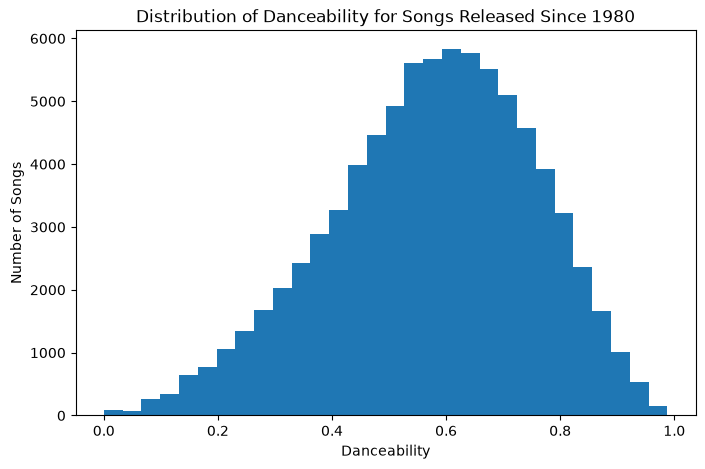

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(data_1980["danceability"], bins=30)

plt.xlabel("Danceability")
plt.ylabel("Number of Songs")
plt.title("Distribution of Danceability for Songs Released Since 1980")

plt.show()

In [8]:
data_1980["danceability"].describe()

count    81201.000000
mean         0.574019
std          0.178623
min          0.000000
25%          0.457000
50%          0.588000
75%          0.706000
max          0.988000
Name: danceability, dtype: float64

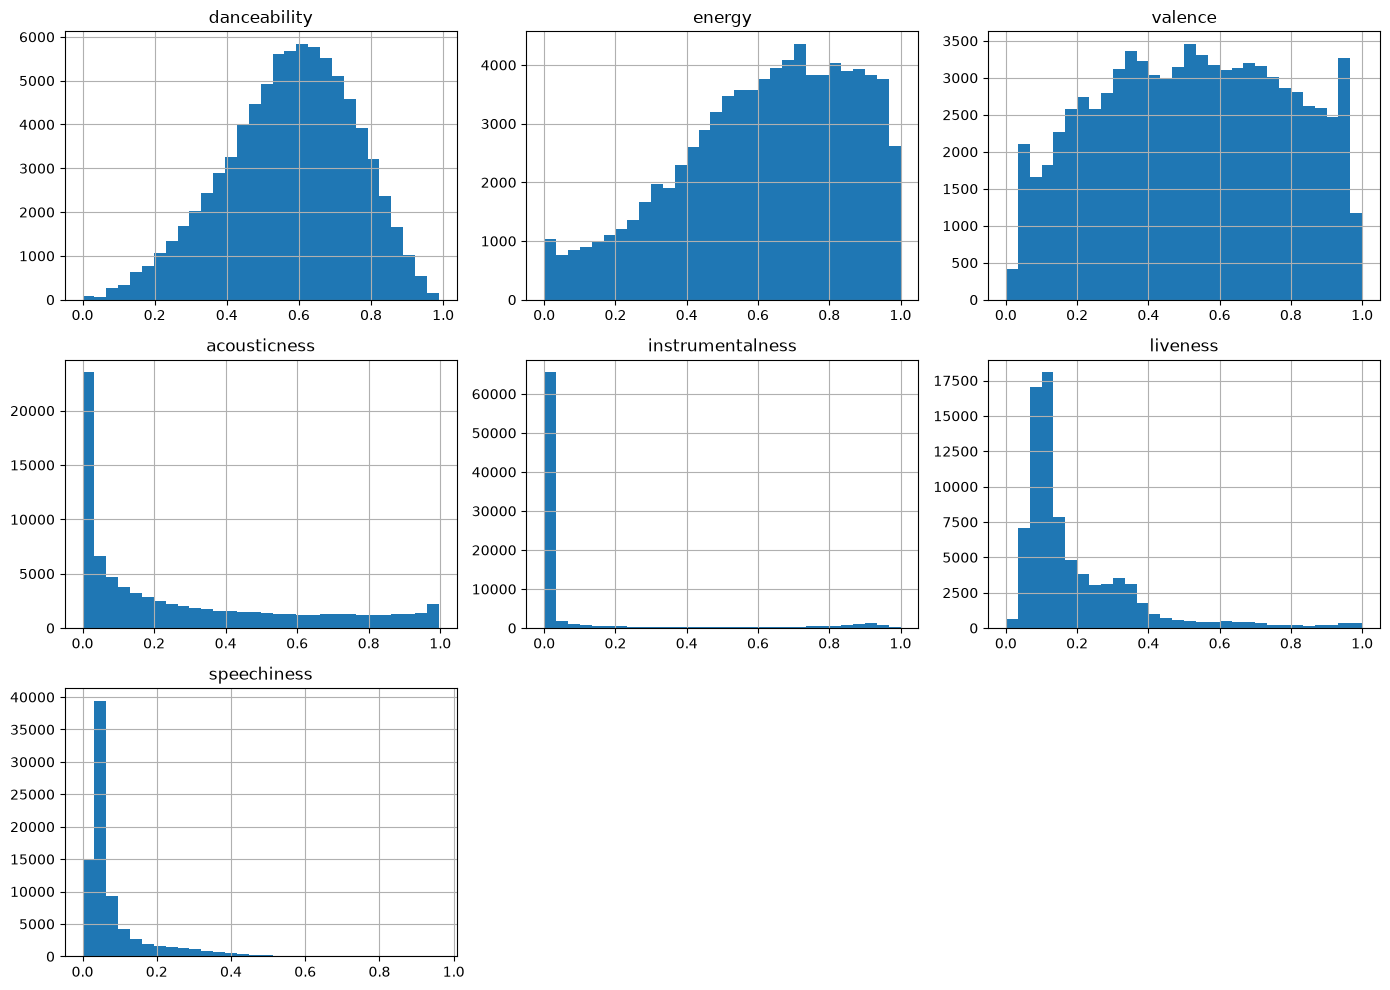

In [9]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness"
]

data_1980[audio_features].hist(
    bins=30,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

In [10]:
data_1980.isnull().sum()

valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64

In [11]:
data_1980.duplicated().sum()

np.int64(0)

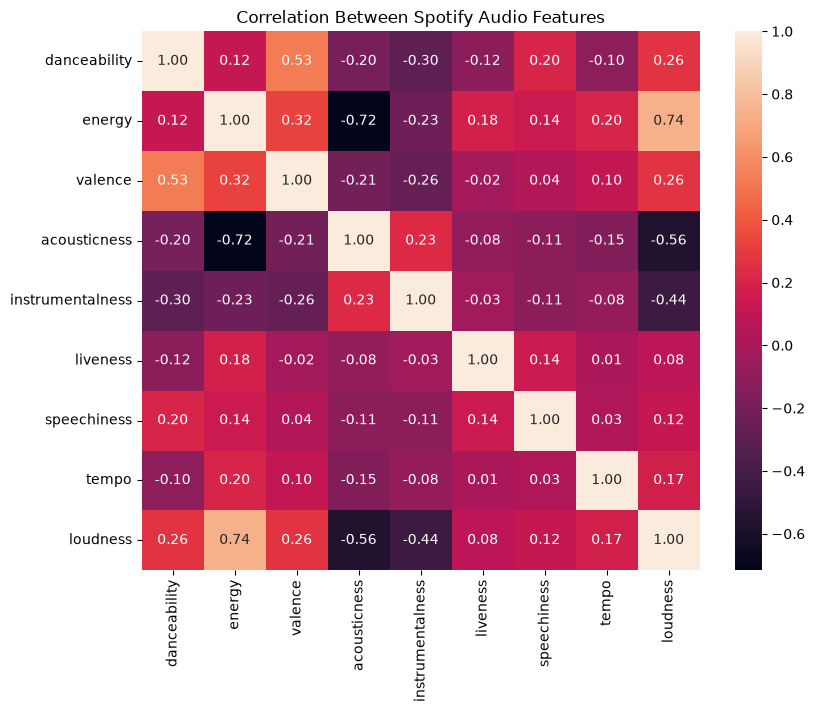

In [58]:
correlation = data_1980[audio_features].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Spotify Audio Features")
plt.savefig(
    "../images/correlation_between_audio_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
danceability_by_year = (
    data_1980
    .groupby("year")["danceability"]
    .mean()
)

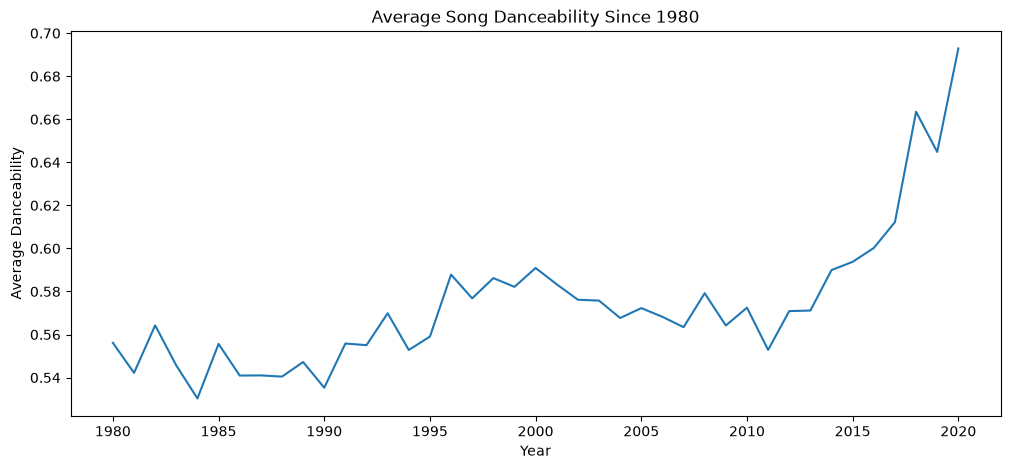

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    danceability_by_year.index,
    danceability_by_year.values
)

plt.xlabel("Year")
plt.ylabel("Average Danceability")
plt.title("Average Song Danceability Since 1980")

plt.show()

In [15]:
model_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "loudness"
]

In [16]:
songs_per_year = data_1980.groupby("year").size()

songs_per_year

year
1980    1950
1981    2000
1982    2000
1983    2000
1984    2000
1985    2000
1986    2000
1987    1950
1988    1950
1989    2000
1990    2000
1991    1950
1992    2000
1993    2000
1994    2000
1995    2000
1996    2000
1997    2000
1998    2000
1999    1951
2000    1956
2001    2005
2002    2000
2003    1954
2004    1966
2005    1950
2006    1950
2007    1950
2008    1955
2009    1960
2010    2016
2011    2017
2012    1945
2013    1976
2014    2005
2015    1974
2016    1797
2017    1992
2018    2103
2019    1949
2020    2030
dtype: int64

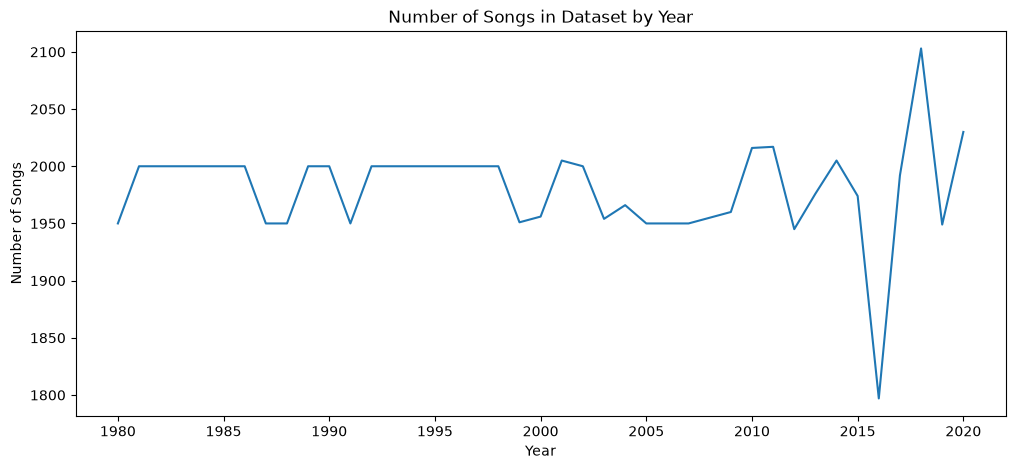

In [57]:
plt.figure(figsize=(12, 5))

plt.plot(
    songs_per_year.index,
    songs_per_year.values
)

plt.xlabel("Year")
plt.ylabel("Number of Songs")
plt.title("Number of Songs in Dataset by Year")
plt.savefig(
    "../images/number_of_songs_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
trend_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness"
]

yearly_features = (
    data_1980
    .groupby("year")[trend_features]
    .mean()
)

In [19]:
yearly_features.head()

,danceability,energy,valence,acousticness
year,,,,
1980,0.556152,0.597777,0.598058,0.284955
1981,0.542185,0.599383,0.582952,0.301204
1982,0.564259,0.590919,0.586438,0.289580
1983,0.545629,0.601425,0.572120,0.294778
1984,0.530309,0.591092,0.551639,0.287710


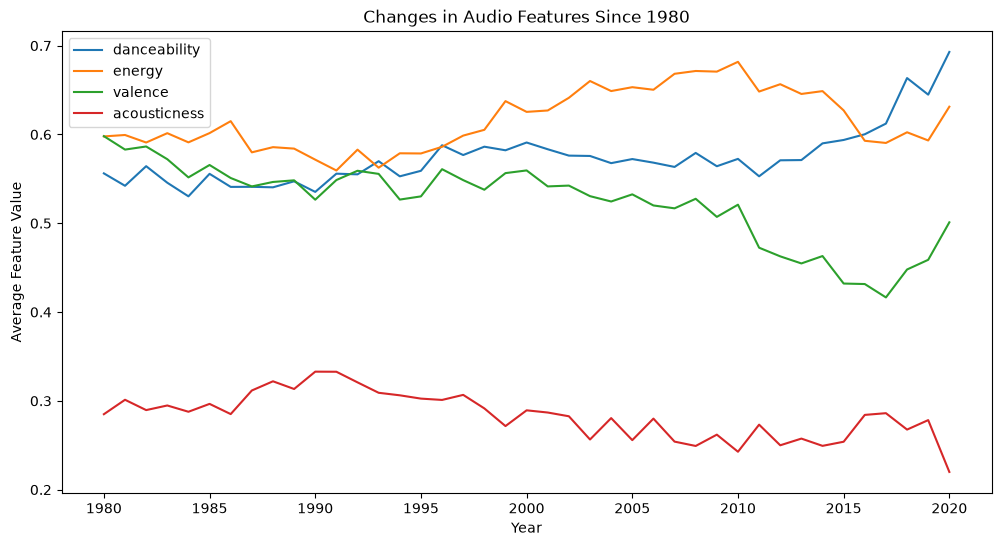

In [56]:
plt.figure(figsize=(12, 6))

for feature in trend_features:
    plt.plot(
        yearly_features.index,
        yearly_features[feature],
        label=feature
    )

plt.xlabel("Year")
plt.ylabel("Average Feature Value")
plt.title("Changes in Audio Features Since 1980")
plt.legend()
plt.savefig(
    "../images/audio_feature_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "loudness"
]

correlation_matrix = data_1980[audio_features].corr()

In [22]:
recommendation_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "liveness",
    "speechiness",
    "tempo",
    "loudness"
]

In [23]:
data_model = data_1980.dropna(
    subset=recommendation_features
).copy()

In [24]:
print(data_1980.shape)
print(data_model.shape)

(81201, 19)
(81201, 19)


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    data_model[recommendation_features]
)

scaled_features.shape

(81201, 9)

In [26]:
favorite_titles = [
    "Billie Jean",
    "Sunflower",
    "Sanguine Paradise",
    "Space Cadet",
    "20 Min",
    "Congratulations"
]

data_model[
    data_model["name"].isin(favorite_titles)
][["name", "artists", "year"]]

,name,artists,year
12007,Billie Jean,['Michael Jackson'],1982
12093,Billie Jean,['Michael Jackson'],1982
18811,Congratulations,"['Post Malone', 'Quavo']",2016
19007,20 Min,['Lil Uzi Vert'],2017
19052,Sunflower,['Rex Orange County'],2017
19484,Sanguine Paradise,['Lil Uzi Vert'],2019
33392,Space Cadet,['Kyuss'],1994
36560,Congratulations,['MGMT'],2010
52294,Billie Jean,['Michael Jackson'],1995
55799,Billie Jean,['The Civil Wars'],2012


In [27]:
data_model[
    data_model["name"].str.contains(
        "20 Min",
        case=False,
        na=False,
        regex=False
    )
][["name", "artists", "year"]]

,name,artists,year
19007,20 Min,['Lil Uzi Vert'],2017
140334,20 Min - Chopped and Screwed,['DJ Purpberry'],2018


In [28]:
favorite_songs = [
    {"name": "Billie Jean", "artist": "Michael Jackson"},
    {"name": "Sunflower", "artist": "Post Malone"},
    {"name": "Happier", "artist": "Marshmello"},
    {"name": "Sanguine Paradise", "artist": "Lil Uzi Vert"},
    {"name": "Congratulations", "artist": "Post Malone"},
    {"name": "Space Cadet", "artist": "Metro Boomin"}
]

In [29]:
favorite_rows = []

for song in favorite_songs:
    matches = data_model[
        (data_model["name"].str.lower() == song["name"].lower()) &
        (data_model["artists"].str.contains(
            song["artist"],
            case=False,
            na=False,
            regex=False
        ))
    ]

    favorite_rows.append(matches)

favorite_data = pd.concat(favorite_rows)

favorite_data[
    ["name", "artists", "year"] + recommendation_features
]

,name,artists,year,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,tempo,loudness
12007,Billie Jean,['Michael Jackson'],1982,0.920,0.654,0.847,0.0236,0.0158,0.0359,0.0401,117.046,-3.051
12093,Billie Jean,['Michael Jackson'],1982,0.932,0.457,0.884,0.0173,0.0436,0.0414,0.0541,117.002,-9.620
52294,Billie Jean,['Michael Jackson'],1995,0.920,0.579,0.838,0.0168,0.0530,0.0419,0.0414,117.084,-5.517
19232,Happier,"['Marshmello', 'Bastille']",2018,0.687,0.792,0.671,0.1910,0.0000,0.1670,0.0452,100.015,-2.749
19484,Sanguine Paradise,['Lil Uzi Vert'],2019,0.729,0.603,0.207,0.0948,0.0000,0.1130,0.0666,134.972,-6.736
18811,Congratulations,"['Post Malone', 'Quavo']",2016,0.630,0.804,0.492,0.2150,0.0000,0.2530,0.0363,123.146,-4.183
154620,Congratulations,"['Post Malone', 'Quavo']",2016,0.629,0.807,0.493,0.2040,0.0000,0.2520,0.0371,122.997,-4.255


In [30]:
data_model = data_model.drop_duplicates(
    subset=["name", "artists", "year"]
).reset_index(drop=True)

In [31]:
data_model.duplicated(
    subset=["name", "artists", "year"]
).sum()

np.int64(0)

In [32]:
data_model = (
    data_1980
    .dropna(subset=recommendation_features)
    .drop_duplicates(subset=["name", "artists", "year"])
    .reset_index(drop=True)
    .copy()
)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    data_model[recommendation_features]
)

In [34]:
favorite_data[
    ["name", "artists", "year"]
]

,name,artists,year
12007,Billie Jean,['Michael Jackson'],1982
12093,Billie Jean,['Michael Jackson'],1982
52294,Billie Jean,['Michael Jackson'],1995
19232,Happier,"['Marshmello', 'Bastille']",2018
19484,Sanguine Paradise,['Lil Uzi Vert'],2019
18811,Congratulations,"['Post Malone', 'Quavo']",2016
154620,Congratulations,"['Post Malone', 'Quavo']",2016


In [35]:
favorite_indices = favorite_data.index

In [36]:
favorite_scaled = scaler.transform(
    favorite_data[recommendation_features]
)

In [37]:
user_profile = favorite_scaled.mean(axis=0)
print(user_profile)

[ 1.14704105  0.23713266  0.41902433 -0.57737433 -0.3361478  -0.39188592
 -0.38927086 -0.06119503  0.77249315]


In [38]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    user_profile.reshape(1, -1),
    scaled_features
)[0]

In [39]:
results = data_model.copy()

results["similarity"] = similarities

In [40]:
results[
    ["name", "artists", "year", "similarity"]
].sort_values(
    "similarity",
    ascending=False
).head(20)

,name,artists,year,similarity
7033,Cheerleader - Felix Jaehn Remix Radio Edit,['OMI'],2015,0.982816
13638,L.E.S. Artistes,['Santigold'],2008,0.981987
54661,Swish Swish,"['Katy Perry', 'Nicki Minaj']",2017,0.980620
27747,Just Got Paid,['*NSYNC'],2000,0.978828
7832,The Man,['Taylor Swift'],2019,0.976230
61347,Mr. Simple,['SUPER JUNIOR'],2011,0.975792
70225,Introvert (feat. Joji),"['Rich Brian', 'Joji']",2018,0.974453
45183,El Cuchillo,['Optimo'],2008,0.974270
38570,Cheerleader - Felix Jaehn Remix Radio Edit,"['OMI', 'Felix Jaehn']",2015,0.973867
7935,Take You Dancing,['Jason Derulo'],2020,0.973208


In [41]:
def create_song_key(df):
    return (
        df["name"].str.lower().str.strip()
        + "|"
        + df["artists"].astype(str).str.lower().str.strip()
    )

In [42]:
favorite_keys = set(create_song_key(favorite_data))

results["song_key"] = create_song_key(results)

In [43]:
recommendations = results[
    ~results["song_key"].isin(favorite_keys)
]

In [44]:
recommendations = (
    recommendations
    .sort_values("similarity", ascending=False)
    .head(10)
)

recommendations

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,...,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,similarity,song_key
7033,0.594,2015,0.141000,['OMI'],0.780,180560,0.680,0,023OVLNzXhX0j7CxswUt6D,0.000012,...,0.1380,-6.081,1,Cheerleader - Felix Jaehn Remix Radio Edit,65,2015-10-16,0.0305,118.026,0.982816,cheerleader - felix jaehn remix radio edit|['o...
13638,0.726,2008,0.034800,['Santigold'],0.869,204907,0.796,0,4dmCLAZbWYT0qtcG7GVMdb,0.000010,...,0.1110,-2.001,1,L.E.S. Artistes,52,2008-04-29,0.0340,117.990,0.981987,l.e.s. artistes|['santigold']
54661,0.583,2017,0.018400,"['Katy Perry', 'Nicki Minaj']",0.838,242520,0.705,1,3OtMnyUaiipcAT23A8liyi,0.000018,...,0.1020,-5.201,0,Swish Swish,69,2017-06-09,0.0449,119.953,0.980620,"swish swish|['katy perry', 'nicki minaj']"
27747,0.695,2000,0.014500,['*NSYNC'],0.809,248573,0.773,0,1eV2FGbbyxCJ6xaLqBRiFW,0.000001,...,0.0876,-3.638,0,Just Got Paid,44,2000-03-21,0.0437,114.842,0.978828,just got paid|['*nsync']
7832,0.633,2019,0.076700,['Taylor Swift'],0.777,190360,0.658,0,3RauEVgRgj1IuWdJ9fDs70,0.000000,...,0.0901,-5.191,1,The Man,79,2019-08-23,0.0540,110.048,0.976230,the man|['taylor swift']
61347,0.795,2011,0.000219,['SUPER JUNIOR'],0.913,241827,0.745,0,6QTBYKLlV2PQniwAWrBV2z,0.002080,...,0.0622,-2.837,1,Mr. Simple,58,2011-08-02,0.0506,127.996,0.975792,mr. simple|['super junior']
70225,0.632,2018,0.140000,"['Rich Brian', 'Joji']",0.836,222259,0.686,1,3qbqWUDl9j09PeBaQ6CZgr,0.002310,...,0.0681,-4.673,1,Introvert (feat. Joji),62,2018-02-02,0.0413,110.029,0.974453,"introvert (feat. joji)|['rich brian', 'joji']"
45183,0.720,2008,0.060400,['Optimo'],0.876,221760,0.714,0,51sf8K5TcoLvuMF24c84Lv,0.000000,...,0.1490,-4.641,0,El Cuchillo,48,2008-07-21,0.0420,128.042,0.974270,el cuchillo|['optimo']
38570,0.614,2015,0.146000,"['OMI', 'Felix Jaehn']",0.777,181827,0.663,0,2XPc8gL9PwxGURQFcFaDJR,0.000015,...,0.1740,-6.117,1,Cheerleader - Felix Jaehn Remix Radio Edit,54,2015-03-06,0.0305,118.016,0.973867,cheerleader - felix jaehn remix radio edit|['o...
7935,0.753,2020,0.033200,['Jason Derulo'],0.789,190306,0.711,0,59qrUpoplZxbIZxk6X0Bm3,0.000000,...,0.0876,-4.248,1,Take You Dancing,92,2020-07-22,0.0410,112.985,0.973208,take you dancing|['jason derulo']


In [45]:
def recommend_songs(
    favorite_data,
    data_model,
    scaler,
    scaled_features,
    recommendation_features,
    n=10
):

    favorite_scaled = scaler.transform(
        favorite_data[recommendation_features]
    )

    user_profile = favorite_scaled.mean(axis=0)

    similarities = cosine_similarity(
        user_profile.reshape(1, -1),
        scaled_features
    )[0]

    results = data_model.copy()
    results["similarity"] = similarities

    favorite_keys = set(create_song_key(favorite_data))
    results["song_key"] = create_song_key(results)

    results = results[
        ~results["song_key"].isin(favorite_keys)
    ]

    return (
        results
        .sort_values("similarity", ascending=False)
        .head(n)[
            ["name", "artists", "year", "similarity"]
        ]
    )

In [46]:
test_song = favorite_data.iloc[[0]]

training_favorites = favorite_data.drop(
    index=test_song.index
)

In [47]:
training_scaled = scaler.transform(
    training_favorites[recommendation_features]
)

test_profile = training_scaled.mean(axis=0)

In [48]:
test_similarities = cosine_similarity(
    test_profile.reshape(1, -1),
    scaled_features
)[0]

In [49]:
evaluation_results = data_model.copy()

evaluation_results["similarity"] = test_similarities

evaluation_results = evaluation_results.sort_values(
    "similarity",
    ascending=False
).reset_index(drop=True)

evaluation_results

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,similarity
0,0.5940,2015,0.1410,['OMI'],0.7800,180560,0.6800,0,023OVLNzXhX0j7CxswUt6D,0.000012,4,0.138,-6.081,1,Cheerleader - Felix Jaehn Remix Radio Edit,65,2015-10-16,0.0305,118.026,0.987637
1,0.5830,2017,0.0184,"['Katy Perry', 'Nicki Minaj']",0.8380,242520,0.7050,1,3OtMnyUaiipcAT23A8liyi,0.000018,5,0.102,-5.201,0,Swish Swish,69,2017-06-09,0.0449,119.953,0.984495
2,0.7260,2008,0.0348,['Santigold'],0.8690,204907,0.7960,0,4dmCLAZbWYT0qtcG7GVMdb,0.000010,4,0.111,-2.001,1,L.E.S. Artistes,52,2008-04-29,0.0340,117.990,0.979631
3,0.6140,2015,0.1460,"['OMI', 'Felix Jaehn']",0.7770,181827,0.6630,0,2XPc8gL9PwxGURQFcFaDJR,0.000015,4,0.174,-6.117,1,Cheerleader - Felix Jaehn Remix Radio Edit,54,2015-03-06,0.0305,118.016,0.978916
4,0.5830,2008,0.0025,['Vanilla Ice'],0.9790,254467,0.7920,0,3XVozq1aeqsJwpXrEZrDJ9,0.000008,2,0.102,-2.784,1,Ice Ice Baby,70,2008-11-04,0.0388,116.012,0.975657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78581,0.0728,1990,0.9360,"['Johann Sebastian Bach', 'Orpheus Chamber Orc...",0.0891,284000,0.0894,0,6t7lMFHSifu9j8NPMNCv9T,0.748000,2,0.416,-25.653,1,"Orchestral Suite No. 3 in D Major, BWV 1068: 2...",57,1990-01-01,0.0420,80.828,-0.853392
78582,0.0731,1989,0.9570,"['Slovak Philharmonic', 'Jaroslava Horska', 'V...",0.0733,198667,0.0951,0,08B8Ki7qlUoT58Zd1trxkl,0.644000,2,0.568,-24.366,0,"Requiem In D Minor, K. 626: Sequence: VI. Lacr...",35,1989-04-15,0.0418,180.489,-0.853872
78583,0.0353,1980,0.8610,"['John Williams', 'London Symphony Orchestra']",0.1010,388280,0.0430,0,4mDrSbQKLmQlJ3sf19Hg6Q,0.617000,5,0.504,-22.975,0,The City in the Clouds,36,1980-01-01,0.0414,90.097,-0.853940
78584,0.0347,1980,0.9100,"['Wendy Carlos', 'Rachel Elkind']",0.1220,173068,0.2200,0,46onaZFYtcf0JDnLggx7yT,0.844000,4,0.473,-21.677,0,Rocky Mountains,27,1980-05-23,0.0464,149.202,-0.856034


In [50]:
test_name = test_song.iloc[0]["name"]
test_artist = test_song.iloc[0]["artists"]

held_out_result = evaluation_results[
    (evaluation_results["name"] == test_name) &
    (evaluation_results["artists"] == test_artist)
]

held_out_result


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,similarity
67,0.847,1982,0.0236,['Michael Jackson'],0.92,293827,0.654,0,5ChkMS8OtdzJeqyybCc9R5,0.0158,11,0.0359,-3.051,0,Billie Jean,83,1982-11-30,0.0401,117.046,0.945592
435,0.838,1995,0.0168,['Michael Jackson'],0.92,294000,0.579,0,6vR5u5b8JeRESx5nZaIWx6,0.0530,11,0.0419,-5.517,0,Billie Jean,55,1995-06-16,0.0414,117.084,0.898054


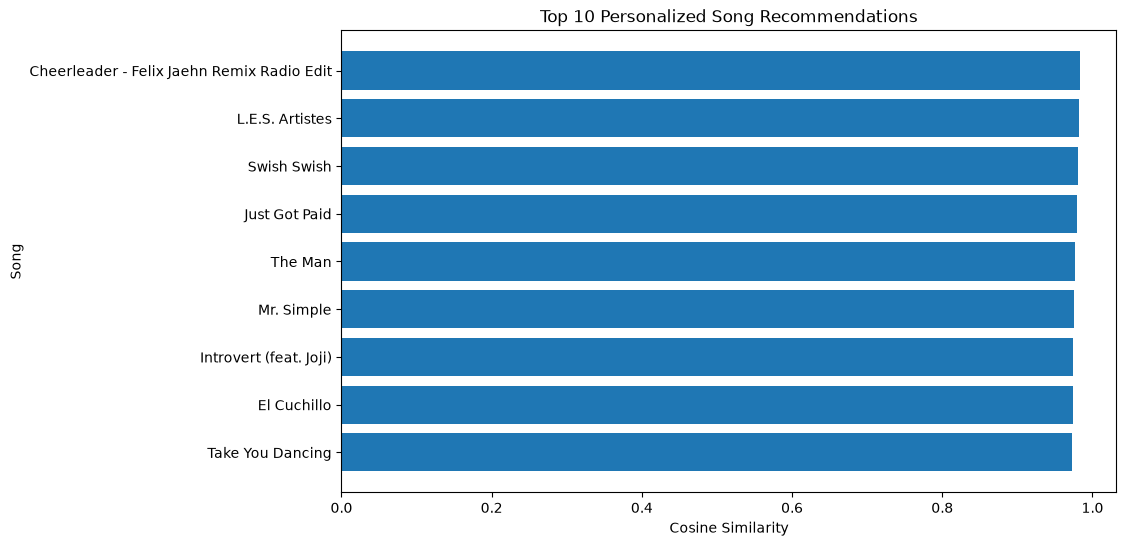

In [51]:
plt.figure(figsize=(10, 6))

plt.barh(
    recommendations["name"],
    recommendations["similarity"]
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Song")
plt.title("Top 10 Personalized Song Recommendations")
plt.savefig(
    "../images/top_recommendationd.png",
    dpi=300,
    bbox_inches="tight"
)

plt.gca().invert_yaxis()

plt.show()

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

song_pca = pca.fit_transform(scaled_features)

song_pca

array([[ 1.10742678, -1.28440549],
       [ 0.24823183,  1.83624019],
       [ 0.94585854,  1.55176316],
       ...,
       [ 1.65822284,  0.0066237 ],
       [ 0.80321637, -0.78634187],
       [ 1.45434207,  1.18665404]], shape=(78586, 2))

In [53]:
pca_df = pd.DataFrame(
    song_pca,
    columns=["PC1", "PC2"]
)

pca_df["name"] = data_model["name"]
pca_df["artists"] = data_model["artists"]

pca_df

,PC1,PC2,name,artists
0,1.107427,-1.284405,Back In Black,['AC/DC']
1,0.248232,1.836240,Wonderful Christmastime - Edited Version / Rem...,['Paul McCartney']
2,0.945859,1.551763,Another One Bites The Dust - Remastered 2011,['Queen']
3,0.399789,1.255471,You Make My Dreams (Come True),['Daryl Hall & John Oates']
4,1.481045,-0.678930,You Shook Me All Night Long,['AC/DC']
...,...,...,...,...
78581,1.638817,0.825662,China,"['Anuel AA', 'Daddy Yankee', 'KAROL G', 'Ozuna..."
78582,1.305121,0.635578,Halloweenie III: Seven Days,['Ashnikko']
78583,1.658223,0.006624,AYA,['MAMAMOO']
78584,0.803216,-0.786342,Darkness,['Eminem']
